# Torus Multimodal (Paper Outputs Only)

This cleaned notebook keeps only the code required to generate:

- `multimodal_tori.pdf` (Figure 5)
- `Tori_summary_table.tex` (Table 3)


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eig

# Ensure imports work whether Jupyter runs from project root or notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from functions import diffusion_map, LG_sym, calc_differential_vec

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'


In [2]:
def cyclic_corr(v_hat: np.ndarray, angle: np.ndarray) -> float:
    c = np.cos(angle)
    s = np.sin(angle)

    c = (c - c.mean()) / np.linalg.norm(c - c.mean())
    s = (s - s.mean()) / np.linalg.norm(s - s.mean())

    return float(np.sqrt(np.dot(v_hat, c) ** 2 + np.dot(v_hat, s) ** 2))


In [3]:
# Generate one representative multimodal torus pair for the panel figure
N = 2000
R = 10
r1 = 4
r2 = 2
RNG_SEED = 42

np.random.seed(RNG_SEED)

x = 2 * np.pi * np.random.uniform(0, 1, N)
y = 2 * np.pi * np.random.uniform(0, 1, N)
z = 2 * np.pi * np.random.uniform(0, 1, N)

A = np.column_stack(((R + r1 * np.cos(y)) * np.cos(x), (R + r1 * np.cos(y)) * np.sin(x), r1 * np.sin(y)))
B = np.column_stack(((R + r2 * np.cos(z)) * np.cos(x), (R + r2 * np.cos(z)) * np.sin(x), r2 * np.sin(z)))


In [4]:
# Core operators/eigenvectors for all methods on the representative sample
P1, Q1, K1 = diffusion_map(A, adaptive=1500)
P2, Q2, K2 = diffusion_map(B, adaptive=1500)

L1, _, v1 = LG_sym(K1)
L2, _, v2 = LG_sym(K2)

_, u1 = calc_differential_vec(L2, v1, 20)
_, u2 = calc_differential_vec(L1, v2, 20)

S = P2 @ Q1 + P1 @ Q2
D = P2 @ Q1 - P1 @ Q2

_, _ = eig(S)  # computed in original workflow; not used directly in final outputs
ea_vals, va = eig(D)
VA_imag = np.imag(va[:, np.argsort(np.imag(ea_vals))[::-1]])
VA_real = np.real(va[:, np.argsort(np.real(ea_vals))[::-1]])

g1 = np.diag(np.sum(K1, axis=1)) - K1
g2 = np.diag(np.sum(K2, axis=1)) - K2

m1 = g1 + 1e-6 * np.eye(g1.shape[0])
m2 = g2 + 1e-6 * np.eye(g2.shape[0])

fk1 = np.linalg.inv(m1 + m2) @ m1
fk2 = np.linalg.inv(m1 + m2) @ m2

fk_vals_1, eig_vec_fk_1 = eig(fk1)
fk_vals_2, eig_vec_fk_2 = eig(fk2)

eig_vec_fk_1 = eig_vec_fk_1[:, np.argsort(fk_vals_1)[::-1]]
eig_vec_fk_2 = eig_vec_fk_2[:, np.argsort(fk_vals_2)[::-1]]


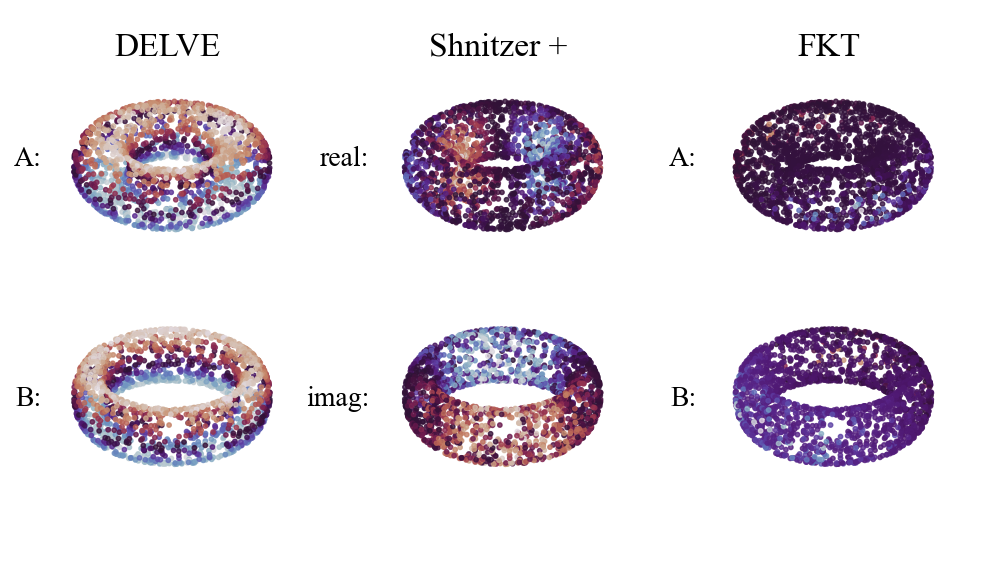

In [5]:
# Output 1: multimodal_tori.pdf
data_dict = {
    '$\delta^A_0$': (A, u2[:, 0]),
    '$v(real)_1$': (A, VA_real[:, 1]),
    '$v(fk)^A_0$': (A, eig_vec_fk_2[:, 0]),
    '$\delta^B_0$': (B, u1[:, 0]),
    '$v(imag)_1$': (B, VA_imag[:, 1]),
    '$v(fk)^B_0$': (B, eig_vec_fk_1[:, 0]),
}

top_row_titles = ['DELVE', 'Shnitzer +', 'FKT']
nrows, ncols = 2, 3

fig = plt.figure(figsize=(4.2 * ncols, 4 * nrows))
cmap = plt.cm.twilight

for i, (_key, (points, values)) in enumerate(data_dict.items()):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=values, cmap=cmap, s=10, alpha=0.8)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    if i < ncols:
        ax.set_title(top_row_titles[i], fontsize=24, y=0.9)

    ax.set_xlabel('')
    ax.set_ylabel('')

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = True
        axis.pane.set_facecolor((1, 1, 1, 0.75))
        axis.pane.set_edgecolor((1, 1, 1, 0))
        axis.line.set_color((0, 0, 0, 0))

    ax.grid(False)
    ax.set_box_aspect([1, 1, 0.3])

z_side_labels = ['A:', 'real:', 'A:', 'B:', 'imag:', 'B:']
for idx, label in enumerate(z_side_labels):
    row = idx // ncols
    col = idx % ncols
    y_pos = 0.65 if row == 0 else 0.35
    x_pos = 0.15 + col * 0.26
    fig.text(x_pos, y_pos, label, fontsize=20, ha='right', va='center')

fig.subplots_adjust(hspace=-0.4, wspace=0.05)
plt.savefig('multimodal_tori.pdf', bbox_inches='tight')
plt.show()


## Summary Table Simulation

In [6]:
def torus_corr(R: float, r1: float, r2: float, N: int, K: int = 1500, k: int = 20):
    x = 2 * np.pi * np.random.uniform(0, 1, N)
    y = 2 * np.pi * np.random.uniform(0, 1, N)
    z = 2 * np.pi * np.random.uniform(0, 1, N)

    X1 = np.column_stack(((R + r1 * np.cos(y)) * np.cos(x), (R + r1 * np.cos(y)) * np.sin(x), r1 * np.sin(y)))
    X2 = np.column_stack(((R + r2 * np.cos(z)) * np.cos(x), (R + r2 * np.cos(z)) * np.sin(x), r2 * np.sin(z)))

    P1, Q1, K1 = diffusion_map(X1, adaptive=K)
    P2, Q2, K2 = diffusion_map(X2, adaptive=K)

    L1, _, v1 = LG_sym(K1)
    L2, _, v2 = LG_sym(K2)

    _, u1 = calc_differential_vec(L2, v1, k)
    _, u2 = calc_differential_vec(L1, v2, k)

    corr_y_dv = cyclic_corr(u2[:, 0], y)
    corr_z_dv = cyclic_corr(u1[:, 0], z)

    S = P2 @ Q1 + P1 @ Q2
    D = P2 @ Q1 - P1 @ Q2
    _, _ = eig(S)
    ea_vals, va = eig(D)

    va_imag = np.imag(va[:, np.argsort(np.imag(ea_vals))[::-1]])
    va_real = np.real(va[:, np.argsort(np.real(ea_vals))[::-1]])

    corr_y_sh_real = cyclic_corr(va_real[:, 0], y)
    corr_y_sh_imag = cyclic_corr(va_imag[:, 0], y)
    corr_z_sh_real = cyclic_corr(va_real[:, 0], z)
    corr_z_sh_imag = cyclic_corr(va_imag[:, 0], z)

    g1 = np.diag(np.sum(K1, axis=0)) - K1
    g2 = np.diag(np.sum(K2, axis=0)) - K2

    m1 = g1 + 1e-6 * np.eye(g1.shape[0])
    m2 = g2 + 1e-6 * np.eye(g2.shape[0])

    fk1 = np.linalg.inv(m1 + m2) @ m1
    fk2 = np.linalg.inv(m1 + m2) @ m2

    fk_values_1, eig_vec_fk_1 = eig(fk1)
    fk_values_2, eig_vec_fk_2 = eig(fk2)

    eig_vec_fk_1 = eig_vec_fk_1[:, np.argsort(fk_values_1)[::-1]]
    eig_vec_fk_2 = eig_vec_fk_2[:, np.argsort(fk_values_2)[::-1]]

    corr_y_fk = cyclic_corr(eig_vec_fk_2[:, 0], y)
    corr_z_fk = cyclic_corr(eig_vec_fk_1[:, 0], z)

    return (
        corr_y_dv,
        corr_z_dv,
        corr_y_sh_real,
        corr_y_sh_imag,
        corr_z_sh_real,
        corr_z_sh_imag,
        corr_y_fk,
        corr_z_fk,
    )


In [ ]:
# Output 2: Tori_summary_table.tex
C = 500
acc_torus = np.zeros((C, 8))

for i in range(C):
    acc_torus[i, :] = torus_corr(R=10, r1=4, r2=2, N=2000, K=1500, k=20)

columns = [
    'DiLVE (y)', 'DiLVE (z)',
    'Shnitzer et al. (real) (y)', 'Shnitzer et al. (imag) (y)',
    'Shnitzer et al. (real) (z)', 'Shnitzer et al. (imag) (z)',
    'FK (y)', 'FK (z)',
]

df = pd.DataFrame(np.abs(acc_torus), columns=columns)

methods = ['DiLVE', 'Shnitzer et al. (real)', 'Shnitzer et al. (imag)', 'FK']
summary = pd.DataFrame(columns=['$\phi^A$ - Mean (SD)', '$\phi^B$ - Mean (SD)'], index=methods)

for method in methods:
    col_y = f'{method} (y)'
    col_z = f'{method} (z)'
    summary.loc[method, '$\phi^A$ - Mean (SD)'] = f"{df[col_y].mean():.3f} ({df[col_y].std():.3f})"
    summary.loc[method, '$\phi^B$ - Mean (SD)'] = f"{df[col_z].mean():.3f} ({df[col_z].std():.3f})"

display(summary.T)
summary.T.to_latex('Tori_summary_table.tex', index=True, float_format='%.3f')


In [ ]:
summary